# Constrained, nonlinear optimization of forearm muscle forces (n=5)
This problem seeks to minimize a physiological cost function (sum of muscle stresses raised to the power n) subject to moment equilibrium about the elbow and enforcing the requirement that muscle forces must be nonnegative.

    u = sum_i ( F_i / PCSA_i ) ** n

This notebook uses **n=5** with initial guess **F0 = (0, 0, 0)**. Larger n penalizes large individual muscle stresses more steeply, driving the solution toward more evenly distributed (lower peak) muscle stress across the three muscles: Brachialis (F1), Biceps Brachii (F2), and Brachoradialis (F3).

There will be separate blocks for performing the nonlinear optimization, a block for calculating the joint reaction force from the muscle forces, and a block for visualizing the output.

We make use of the SciPy constrained optimization routine here, Sequential Least SQuares Programming (SLSQP) Algorithm but that is not the only one we can use.

Consider visiting https://docs.scipy.org/doc/scipy/tutorial/optimize.html#


In [1]:
# Solve the nonlinear optimization problem

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from forearm_optimization import solve_forearm_forces, solve_jrf

n = 5
F0 = np.zeros(3)  # initial conditions: F0 = (0, 0, 0)

result = solve_forearm_forces(n=n, F0=F0)
F1, F2, F3 = result.x
print(f"F1 = {F1:.2f}, F2 = {F2:.2f}, F3 = {F3:.2f}")
print(f"Cost = {result.fun:.2f}")


F1 = 64.22, F2 = 69.48, F3 = 39.46
Cost = 10.44


# Here we will solve for the joint reaction force (JRF) at the elbow
This next block passes the optimal (F1, F2, F3) from `result.x` and calculates the joint reaction forces, FJx and FJy, and their resultant magnitude and direction.

In [2]:
# Solve for the JRF

theta = (80.0, 70.0, 20.0)
Fb, Fg = 20.0, 10.0

JointX, JointY, mag, angled = solve_jrf(F1, F2, F3, theta=theta, Fb=Fb, Fg=Fg)

print(f"F1 = {F1:.2f}, F2 = {F2:.2f}, F3 = {F3:.2f}")
print(f"JRF has magnitude in N and acts with angle in degrees = {mag:.2f}, {angled:.2f}")


F1 = 64.22, F2 = 69.48, F3 = 39.46
JRF has magnitude in N and acts with angle in degrees = 133.17, -57.28


# Visualize results
This block plots the muscle forces and JRF magnitude as a bar plot.

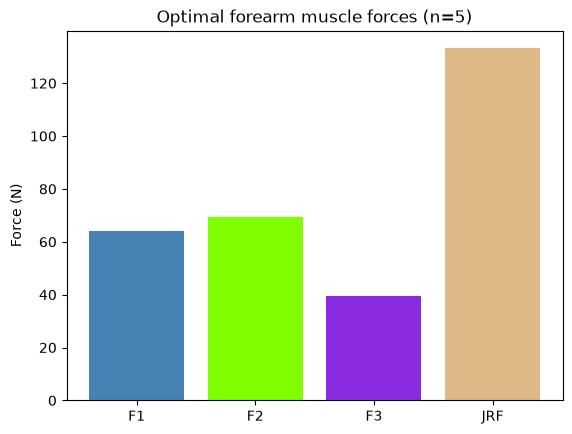

Saved forearm_optimization_n5.png


In [3]:
# Plot the optimal forearm muscle forces and JRF

labels = ["F1", "F2", "F3", "JRF"]
values = list(result.x) + [mag]
fig, ax = plt.subplots()
ax.bar(labels, values, color=["steelblue", "chartreuse", "blueviolet", "burlywood"])
ax.set_ylabel("Force (N)")
ax.set_title(f"Optimal forearm muscle forces (n={n})")
fig.savefig("forearm_optimization_n5.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved forearm_optimization_n5.png")
